Prioritization of ligands based on expression values
================

In this notebook, we will extend the basic NicheNet analysis from [Perform NicheNet analysis: step-by-step analysis](steps.ipynb) by incorporating gene expression as part of the prioritization. While the original NicheNet only ranks ligands based on the ligand activity analysis, it is now also possible to prioritize ligands based on cell type and condition specificity of the ligand and receptor. We will again make use of mouse NICHE-seq data to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after lymphocytic choriomeningitis virus (LCMV) infection (Medaglia et al. 2017). 

Make sure you understand the different steps in a NicheNet analysis that are described in the basic vignette before proceeding with this tutorial.

# Prepare NicheNet analysis

Load required packages

In [1]:
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import LigandReceptorNetwork, WeightedNetwork
from nichenetpy.wrappers import (
    run_nichenet,
    generate_info_tables,
    create_ligand_receptor_links_circos_plot
)
from nichenetpy.utils import ligand_activities_df
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.prioritization import (
    generate_prioritization_table,
    process_table_to_ic,
    calculate_de,
    get_avg_exp
)
from nichenetpy.metrics import group_metrics
from nichenetpy.io import read_ligand_target_matrix

import anndata
import pandas as pd
import os
import requests

Download the model files

In [2]:
model_path = os.path.normpath("./tutorial_files/model/mouse")
if not os.path.exists(model_path):
    os.makedirs(model_path)
for filename in (
    "gr_mouse.bin",
    "ligand_target_matrix_mouse.bin",
    "lr_network_mouse.bin",
    "lr_sig_mouse.bin"
):
    file_path = os.path.join(model_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14858034/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

Download the AnnData object

In [3]:
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14859451/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

In [4]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
ann.var_names = ann.var["gene"]
mouse_alias_info.alias_to_symbol(ann)
predictor = LigandActivityPredictor(*read_ligand_target_matrix(os.path.join(model_path, "ligand_target_matrix_mouse.bin")))
lr_network = LigandReceptorNetwork(filename=os.path.join(model_path, "lr_network_mouse.bin"))
lr_sig = WeightedNetwork(filename=os.path.join(model_path, "lr_sig_mouse.bin"))

# Perform the NicheNet analysis

We will use the sender-focused approach here.

In [5]:
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
res = run_nichenet(
    ann,
    predictor,
    lr_network,
    "CD8 T",
    "aggregate",
    "LCMV",
    "SS",
    sender_celltypes=sender_celltypes,
)
ligand_activities_sorted = res["ligand_activities_sorted_focused"]
best_upstream_ligands = res["best_upstream_ligands_focused"]
expressed_ligands = res["expressed_ligands"]
expressed_receptors = res["expressed_receptors"]

# Perform prioritization of ligand-receptor pairs

We will prioritize ligand-receptor pairs based on the following criteria
(with their corresponding weight names):

- Upregulation of the ligand in a sender cell type compared to other
  cell types: `de_ligand`
- Upregulation of the receptor in a receiver cell type: `de_receptor`
- Average expression of the ligand in the sender cell type:
  `exprs_ligand`
- Average expression of the receptor in the receiver cell type:
  `exprs_receptor`
- Condition-specificity of the ligand across all cell types:
  `ligand_condition_specificity`
- Condition-specificity of the receptor across all cell types:
  `receptor_condition_specificity`

This means that we will have to calculate:

- Differential expression of the ligand/receptor in a sender/receiver
  cell type
- The average expression of each ligand/receptor in each sender/receiver
  cell type
- Differential expression of the ligand/receptor between the two
  conditions

We provide a wrapper function `generate_info_tables` that will calculate
all these values for you. This function returns a list with three
dataframes:

- `sender_receiver_de`: differential expression of the ligand and
  receptor in the sender-receiver cell type pair. These were first
  calculated separately (i.e., DE of ligand in sender cell type, DE of
  receptor in receiver cell type based on FindAllMarkers) and then
  combined based on possible interactions from the lr_network.
- `sender_receiver_info`: the average expression of the ligand and
  receptor in sender-receiver cell type pairs
- `lr_condition_de`: differential expression of the ligand and receptor
  between the two conditions across all cell types.

Note that cell type specificity (i.e., the first four conditions) is
calculated only in the condition of interest.

The “scenario” argument can be either “case_control” or “one_condition”.
In “case_control” scenario, condition specificity is calculated.

In [6]:
lr_network_filtered = lr_network.subset_sep(expressed_ligands, expressed_receptors)
info_tables = generate_info_tables(
    ann,
    "celltype",
    sender_celltypes,
    ["CD8 T"],
    lr_network_filtered,
    "aggregate",
    "LCMV",
    "SS",
    case_control=True
)

Next, we generate the prioritization table. This table contains the rankings of ligand-receptor pairs based on the different criteria. We provide two scenarios: case_control and one_condition. In the “case_control” scenario, all weights are set to 1. If “one_condition”, the weights are set to 0 for condition specificity and 1 for the remaining criteria. Users can also provide their own weights using the prioritizing_weights argument.

In [7]:
prior_table = generate_prioritization_table(
    info_tables["sender_receiver_info"],
    info_tables["sender_receiver_de"],
    ligand_activities_sorted,
    info_tables["lr_condition_de"]
)

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
prior_table[["sender", "receiver", "ligand", "receptor", "prioritization_score"]].drop_duplicates()

,sender,receiver,ligand,receptor,prioritization_score
381,NK,CD8 T,Ptprc,Dpp4,0.839420
409,Mono,CD8 T,Ptprc,Dpp4,0.823103
444,Treg,CD8 T,Ptprc,Dpp4,0.801749
63,Mono,CD8 T,Cxcl10,Dpp4,0.794262
464,B,CD8 T,Ptprc,Dpp4,0.793503
...,...,...,...,...,...
1129,DC,CD8 T,Thy1,Itgb2,0.141081
915,CD4 T,CD8 T,Lgals1,Itgb1,0.135276
732,DC,CD8 T,Mif,Cxcr4,0.133613
773,Mono,CD8 T,Mif,Cxcr4,0.133107


### step-by-step prioritization

In [9]:
sender_receiver_de = process_table_to_ic(
    calculate_de(
        ann,
        "celltype",
        "LCMV",
        "aggregate",
        features=lr_network_filtered.get_ligands().union(lr_network_filtered.get_receptors())
    ),
    "celltype_DE",
    lr_network_filtered,
    sender_celltypes,
    ["CD8 T"]
)
sender_receiver_info = process_table_to_ic(
    get_avg_exp(
        ann,
        "celltype",
        "LCMV",
        "aggregate"
    ),
    "expression",
    lr_network_filtered
)
group_metrics(
    ann,
    groupby="aggregate",
    group_oi="LCMV",
    group_ref="SS"
)
res = ann.uns["group_metrics"]
lr_condition_de = process_table_to_ic(
    res[["gene", "lfc", "pval", "pval_adj"]],
    "group_DE",
    lr_network_filtered
)

And here is how you can define custom weights:

In [10]:
prioritizing_weights = {
    "de_ligand": 1,
    "de_receptor": 1,
    "activity_scaled": 1,
    "exprs_ligand": 1,
    "exprs_receptor": 1,
    "ligand_condition_specificity": 1,
    "receptor_condition_specificity": 1
}
prior_table = generate_prioritization_table(
    sender_receiver_info,
    sender_receiver_de,
    ligand_activities_sorted,
    lr_condition_de
)

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Prioritizing across multiple receivers

As NicheNet is a receiver-based pipeline, to prioritize ligand-receptor pairs across multiple receivers, we need to perform the NicheNet analysis for each receiver separately. Let’s suppose we want to prioritize ligand-receptor pairs across all T cells (CD4, CD8, and Tregs). The CD8 T analysis has already been performed above. We will use the wrapper function to perform a basic NicheNet analysis on the other two:

In [11]:
nichenet_output = dict()
for receiver in ("CD8 T", "CD4 T", "Treg"):
    res = run_nichenet(
        ann,
        predictor,
        lr_network,
        receiver,
        "aggregate",
        "LCMV",
        "SS",
        sender_celltypes=sender_celltypes,
    )
    ligand_activities = ligand_activities_df(res["ligand_activities_sorted_focused"])
    ligand_activities["receiver"] = [receiver for _ in range(len(ligand_activities.index))]
    res["ligand_activities"] = ligand_activities
    nichenet_output[receiver] = res


To generate the dataframes used for prioritization, we will simply change the lr_network_filtered argument to only calculate DE and expression values for ligand-receptor pairs of interest.

In [12]:
for receiver, res in nichenet_output.items():
    lr_network_filtered = lr_network.subset_sep(
        res["ligand_activities"].index,
        [gene for gene in res["expressed_genes_receiver"] if gene in predictor.row_names]
    )
    res["info_tables"] = generate_info_tables(
        ann,
        "celltype",
        sender_celltypes,
        [receiver],
        lr_network_filtered,
        "aggregate",
        "LCMV",
        "SS",
        case_control=True
    )
info_tables_combined = {
    key: pd.concat((res["info_tables"][key] for res in nichenet_output.values()))
    for key in ["sender_receiver_de", "sender_receiver_info", "lr_condition_de"]
}
info_tables_combined["sender_receiver_info"].drop_duplicates(inplace=True)
info_tables_combined["lr_condition_de"].drop_duplicates(inplace=True)
ligand_activities_combined = pd.concat((res["ligand_activities"] for res in nichenet_output.values()))
prior_tables_combined = generate_prioritization_table(
    info_tables_combined["sender_receiver_info"],
    info_tables_combined["sender_receiver_de"],
    ligand_activities_combined,
    info_tables_combined["lr_condition_de"]
)

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Extra visualization of ligand-receptor pairs

In [13]:
prior_table_oi = prior_tables_combined.sort_values(by="prioritization_score", ascending=False)[:50]

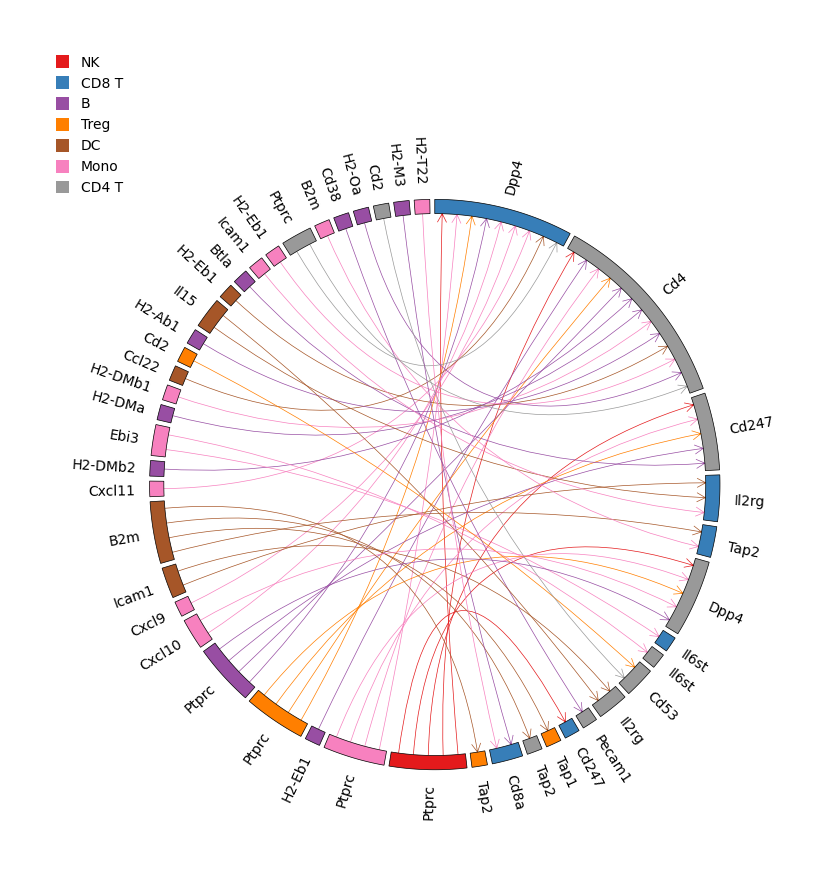

In [14]:
_ = create_ligand_receptor_links_circos_plot(
    prior_table_oi["sender"],
    prior_table_oi["receiver"],
    prior_table_oi["ligand"],
    prior_table_oi["receptor"]
)